In [1]:
# Michele Bianco: 12.04.2025
import numpy as np, random
from scipy.linalg import norm
from tqdm import tqdm

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
import astropy.constants as cst

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from utils_rt import refine_grid_2d
from utils_rtplot import plot_irregular_grid_cells, plot_ray

## Introduction to Ray-Tracing Algorithm

In radiative transfer, **ray tracing** is the process of following the propagation of radiation through a medium that may absorb, emit, or scatter light. To describe the physics governing this process, we compute the intensity of radiation by integrating the radiative transfer equation along a complete ray from the radiation source to every cell (or grid point) in the computational domain.

The one-dimensional radiative transfer equation can be written as:

$$ \frac{dI_\nu}{ds} = j_\nu - \alpha_\nu I_\nu $$

where:  
- $I_\nu$ is the specific intensity,  
- $\alpha_\nu$ is the absorption coefficient,  
- $j_\nu$ is the emission coefficient,  
- $ds$ is an infinitesimal path length along the ray.  

Integrating along a ray, from the source of radiation to a target at distance $s$, gives:

$$ I_\nu(s) = I_\nu(0)e^{-\tau_\nu(s)} + \int_0^s j_\nu(s')\, e^{-[\tau_\nu(s) - \tau_\nu(s')]} \, ds' $$

where $\tau_\nu(s) = \int \alpha_\nu \, ds$ is the optical depth along the path, and $I_\nu(0) \equiv I_0$ is the intrinsic intensity (or luminosity) of the source.  

In practice, one can simplify the equation above by neglecting emission and scattering, leading to the homogeneous solution:

$$ I_\nu(s) = I_\nu(0)\, e^{-\tau_\nu(s)} $$

For a ray that marches through the entire grid, we can compute the optical depth $\tau_\nu$ cell by cell, and then optionally include local emission or scattering terms to calculate the resulting intensity field, given the radiation field at each grid location.

---

There are several methods to implement the ray-tracing process, for example:

- **Long Characteristics** (e.g., Feautrier 1964)  
- **Short Characteristics** (e.g., Kunasz & Auer 1988)  
- **Adaptive Ray Tracing** (e.g., Abel & Wandelt 2002)  
- **Cones** (e.g., Petkova & Springel 2011)  
- **Hybrid Methods** (e.g., Rijkhorst et al. 2006)

In this and the following tutorials, we will focus on the first two methods, as these are the most intuitive and direct ways to simulate the propagation of radiation.

Here, we examine in particular the **long-characteristics method**. This is one of the most direct and accurate ways to solve the radiative transfer equation along discrete lines of sight. The advantage of this method is that it is conceptually simple and highly accurate, as it follows the physical process of photon propagation. However, it becomes computationally expensive for many sources or high-resolution grids — approximately scaling as $\mathcal{O}(N_{\text{src}} N_{\text{cell}}^3)$ — and requires careful interpolation across grid cells to avoid artifacts.


## Define Source & Target Positions

Here, we will **compute a single ray** that originates at the source position $\vec{r}_s$ and is directed toward a specific target cell at position $\vec{r}_t$. Along this line of sight, we will trace the **absorption of radiation** as the ray propagates through the medium.

In [2]:
# box mesh and cell (physical) size
meshsize = 6
dL = 0.1 * u.cm

# position target cell
#r_target = np.array([5.25, 4.25])
r_target = np.array([4.75, 5.25])
print('target:', r_target)

# source position
r_source = np.array([1.5, 1.5])
#r_source = np.array([0.5, 0.5])
print('source:', r_source)

# vector from source to cells
r_st = r_target - r_source
n_st = r_st/norm(r_st)
print('source to target:', n_st)
print('distance:', norm(r_st))

target: [4.75 5.25]
source: [1.5 1.5]
source to target: [0.65493054 0.75568908]
distance: 4.962358310319802


## Define irregular grid

One of the advantages of __long-characteristic raytracing__ algorithms is that they __work on gridded data__ that can have __different spatial resolutions__. To illustrate this, we define a volume with an irregular grid that includes some regions with higher spatial resolution.

In [3]:
# define position of the refinde cells
refine_cells = [(3, 3), (3, 4), (4, 3), (4, 4), (5, 3), (5, 4), (3, 5), (4, 5), (5, 5)]

# define level of the refined cells (resolution: 2^levels, similar to Ramses-RT)
levels = {(3, 3): 2, (3, 4): 1, (4, 3): 1, (4, 4): 1, (5, 3): 1, (5, 4): 1, (3, 5): 1, (4, 5): 1, (5, 5): 1}

# Create refined 2D grid (no specific convention)
x_grid, y_grid, dr = refine_grid_2d(meshsize=meshsize, refine_cells=refine_cells, levels=levels)

# Coordinate of each cells (at the center of the cell)
r_c = np.vstack((x_grid, y_grid)).T

# define density grid
ndens = (4e-31 * u.g/u.cm**3) / (cst.m_p+cst.m_e)  / dr

For simplicity, here we look only at one specific direction.

In [4]:
# only rays in the direction of the the target
mask_x = (r_c[:, 0] <= r_target[0]) * (r_c[:, 0] >= r_source[0])
mask_y = (r_c[mask_x, 1] <= r_target[1]) * (r_c[mask_x, 1] >= r_source[1])

# cells position
r_cell = r_c[mask_x][mask_y]
dr_grid = dr[mask_x][mask_y]

print(r_cell.shape)

(44, 2)



## Optical Depth and Column Density

The optical depth $\tau_\nu$ measures how opaque a medium is to radiation of frequency $\nu$. This quantity is defined as the integral of the absorption coefficient, $\alpha_\nu$, along a path of length $s$.

$$ \tau_\nu = \int \alpha_\nu(s)\, ds$$

If we consider a diffuse gas with one single species (e.g. neutral hydrogen, HI), we can then assume that the opacity due to the absorption coefficient can be written as:

$$ \alpha_\nu(s) = n(s) \, \sigma_\nu $$

Where $n$ is the number density (atoms per cm$^3$) of absorbers, neutral hydrogen in our case. $\sigma_\nu$ is absorption cross section at frequency $\nu$ (atoms aboserbed per area).

This gives:

$$ \tau_\nu = \int n(s)\,\sigma_\nu\,ds = \sigma_\nu \int n(s)\,ds = \sigma_\nu N $$

The integral $\int n(s)\,ds$ is the so-called column density $N$. The column density tells you how many photons are absorbed by the gas along their path, while the $\sigma_\nu$ tells you how likely each atom is to absorb the photon. Their product, $\tau_\nu$, gives the total attenuation experienced by radiation. Just a reminder that, when:
- $\tau_\nu \ll 0$: the medium is optically thin. Therefore, most photons escape.
- $\tau_\nu \gg 1$: the medium is optically thick. Therefore, the photons are absorbed or scattered multiple times.

## Calculate which cells cross the ray

The key goal in raytracing is to calculate the resulting column density, $N$, for each ray. A numerical approach has:

$$N = \int_{LoS} n(s)\,ds = \sum_{i} n_i(s) \Delta s_i$$

In practice, one neeed to compute the crossing distance, $\Delta s_i$, for each cell, $i$, crossed by the ray so to get the discrete integral over the line of sight (LoS).

In raytracing algorithm, the length $\Delta s_i$ can be calculated by solving the geometrical problem of the [line-plane intersection](https://en.wikipedia.org/wiki/Line%E2%80%93plane_intersection). As illustrated by the figure here below.

<img src="img/example_ray.png" alt="Drawing" style="width: 300px;"/>

Therefore:

In [5]:
# source to each cells vector
r_sc = r_cell - r_source

# lenght by dot product
l = r_sc.dot(n_st)

# closest point on the tangent to the cells 
r_p = r_source + l[:,None]*n_st[None,:]

# point onto tanget to cell vector
r_cp = r_p - r_cell

# select only the cell that are touched by the ray
mask = np.array([(np.abs(r_cp[i,0]) <= dr_grid[i]/2) and (np.abs(r_cp[i,1]) <= dr_grid[i]/2) for i in range(dr_grid.size)])

r_touch = r_cell[mask]
dr_touch = dr_grid[mask]

Here we calculated which cell is crossed (touched) by the ray. Thus limiting the calculation of $\Delta s_i$ to thoes cells.

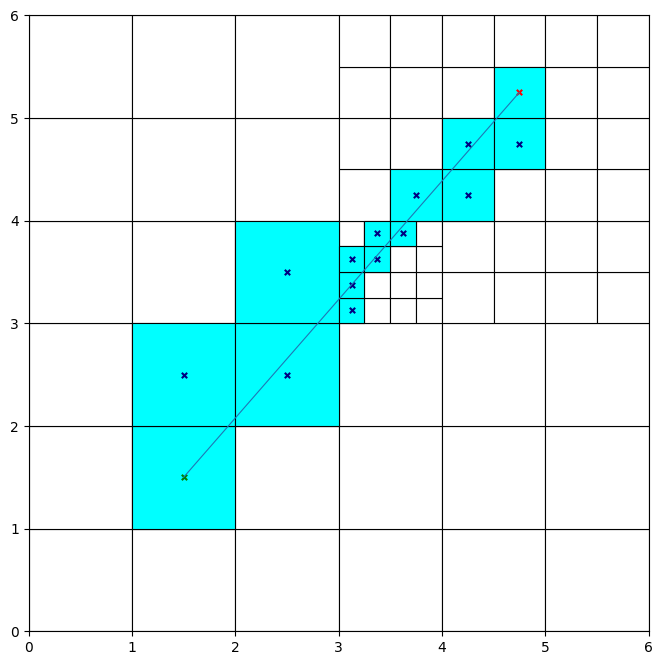

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_c, dr=dr, ax=ax)

# plot cells that are touched by the ray
plot_irregular_grid_cells(r_c=r_touch, dr=dr_touch, color='cyan', ax=ax)

# mark cells that are crossed by the ray
ax.scatter(x=r_touch[1:-1,0], y=r_touch[1:-1,1], s=15, marker='x', color='navy', label='target')

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')

ax.set_xlim(0, meshsize)
ax.set_ylim(0, meshsize)
plt.show()

The blue cells here are the one we need to look at and apply the raytracing algorithm. Loop on them to find the corresponding column density.

In [7]:
for i in range(r_touch.shape[0]):
    print(r_touch[i], r_touch[i] + dr_touch[i]/2)

[1.5 1.5] [2. 2.]
[1.5 2.5] [2. 3.]
[2.5 2.5] [3. 3.]
[2.5 3.5] [3. 4.]
[3.125 3.125] [3.25 3.25]
[3.125 3.375] [3.25 3.5 ]
[3.125 3.625] [3.25 3.75]
[3.375 3.625] [3.5  3.75]
[3.375 3.875] [3.5 4. ]
[3.625 3.875] [3.75 4.  ]
[3.75 4.25] [4.  4.5]
[4.25 4.25] [4.5 4.5]
[4.25 4.75] [4.5 5. ]
[4.75 4.75] [5. 5.]
[4.75 5.25] [5.  5.5]


## Long Charateristic Raytracing

In [8]:
# previous point of interception (init is source position)
r_inter = np.zeros_like(r_touch)
dist = np.zeros(r_touch.shape[0])
dist_prev = 0

for idx in range(r_touch.shape[0]):  
    # vector to the source to the plane
    r_isp = np.array([dr_touch[idx]/2, 0.])
    r_jsp = np.array([0., dr_touch[idx]/2])
    #print(r_isp, r_jsp)
    
    # point on the plane
    p_i0 = r_touch[idx] + r_isp
    p_j0 = r_touch[idx] + r_jsp
    
    # normal vector to the surf
    n_iplan = r_isp/norm(r_isp)
    n_jplan = r_jsp/norm(r_jsp)

    # parametric distance of the plan
    d_i = (p_i0-r_source).dot(n_iplan)/(n_st.dot(n_iplan))
    d_j = (p_j0-r_source).dot(n_jplan)/(n_st.dot(n_jplan))
    
    # id of the cell (use this to get the corresponding density)
    if(d_i < d_j):
        r_inter[idx] = r_source + d_i*n_st
        dist[idx] = d_i - dist_prev
        dist_prev = d_i
    else:
        r_inter[idx] = r_source + d_j*n_st
        dist[idx] = d_j - dist_prev
        dist_prev = d_j

# the last cell it stops to the cells coordinate center
r_inter[-1] = r_touch[-1]

# the distance to the last cell is half that value
dist[-1] = dist[-1]/2

print(dist, dist.size)

[0.66164777 0.10179197 1.22150358 0.3053759  0.02544799 0.33082389
 0.02544799 0.3053759  0.07634397 0.25447991 0.50895983 0.15268795
 0.61075179 0.05089598 0.33082389] 15


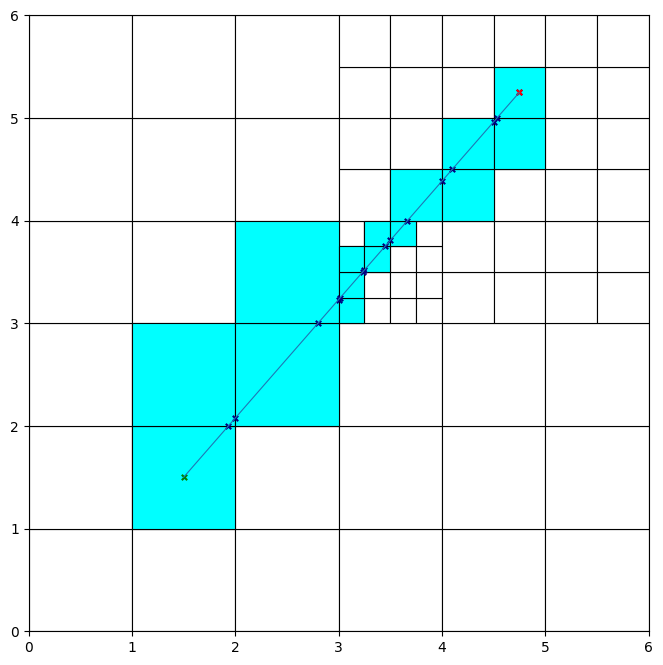

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_c, dr=dr, ax=ax)

# plot cells that are touched by the ray
plot_irregular_grid_cells(r_c=r_touch, dr=dr_touch, color='cyan', ax=ax)

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_inter[:,0], y=r_inter[:,1], s=15, marker='x', color='navy', label='interception')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')

ax.set_xlim(0, meshsize)
ax.set_ylim(0, meshsize)
plt.show()

The density of the cells crossed by the ray:

In [10]:
ndens_los = ndens[mask_x][mask_y][mask]
print(ndens_los)

[0.00023902 0.00023902 0.00023902 0.00023902 0.00095606 0.00095606
 0.00095606 0.00095606 0.00095606 0.00095606 0.00047803 0.00047803
 0.00047803 0.00047803 0.00047803] g / (kg cm3)


The column density of the target cell, $\vec{r}_t$ is:

In [11]:
Ncol = np.sum(dist*dL * ndens[mask_x][mask_y][mask])
print(Ncol)

0.00023113347640835993 g / (kg cm2)
